In [1]:
from pathlib import Path
import json
import re
import warnings

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

PROJECT_ROOT = Path(r"C:\Users\danie\Desktop\Treefera Hackathon")

S2_ROOT = PROJECT_ROOT / "data" / "sentinel2" / "B_grinnell_iowa" / "2017-01-01_2025-12-31"
ZARR_PATH = S2_ROOT / "cube.zarr"

AOI_GEOJSON_PATH = PROJECT_ROOT / "data" / "boundaries" / "B_grinnell_iowa_aoi.geojson"
BIOMASS_ROOT = PROJECT_ROOT / "data" / "biomass"

DEMO_DATA = PROJECT_ROOT / "public" / "demo-data"
DEMO_DATA.mkdir(parents=True, exist_ok=True)

BASELINE_DATE = np.datetime64("2022-01-25")

print("Project root:", PROJECT_ROOT)
print("Zarr exists:", ZARR_PATH.exists())
print("AOI exists:", AOI_GEOJSON_PATH.exists())
print("Biomass folder exists:", BIOMASS_ROOT.exists())

Project root: C:\Users\danie\Desktop\Treefera Hackathon
Zarr exists: True
AOI exists: True
Biomass folder exists: True


In [2]:
ds = xr.open_zarr(ZARR_PATH, consolidated=False)

with open(AOI_GEOJSON_PATH, "r", encoding="utf-8") as f:
    aoi_geojson = json.load(f)

aoi_feature = aoi_geojson["features"][0]
aoi_props = aoi_feature["properties"]

print(ds)
print("\nAOI properties:")
print(json.dumps(aoi_props, indent=2))

<xarray.Dataset> Size: 1GB
Dimensions:      (time: 108, y: 803, x: 806)
Coordinates:
  * time         (time) datetime64[ns] 864B 2017-01-01 2017-02-01 ... 2025-12-01
  * y            (y) float64 6kB 4.625e+06 4.625e+06 ... 4.617e+06 4.617e+06
  * x            (x) float64 6kB 5.193e+05 5.193e+05 ... 5.273e+05 5.273e+05
    spatial_ref  int64 8B ...
Data variables:
    B04          (time, y, x) uint16 140MB dask.array<chunksize=(1, 256, 256), meta=np.ndarray>
    B03          (time, y, x) uint16 140MB dask.array<chunksize=(1, 256, 256), meta=np.ndarray>
    B07          (time, y, x) uint16 140MB dask.array<chunksize=(1, 256, 256), meta=np.ndarray>
    B05          (time, y, x) uint16 140MB dask.array<chunksize=(1, 256, 256), meta=np.ndarray>
    B08          (time, y, x) uint16 140MB dask.array<chunksize=(1, 256, 256), meta=np.ndarray>
    B02          (time, y, x) uint16 140MB dask.array<chunksize=(1, 256, 256), meta=np.ndarray>
    B12          (time, y, x) uint16 140MB dask.array<chun

In [3]:
aoi_payload = {
    "theme": aoi_props.get("theme"),
    "name": aoi_props.get("name"),
    "country": aoi_props.get("country"),
    "approx_size_km": aoi_props.get("approx_size_km"),
    "note": aoi_props.get("note"),
    "geometry_type": aoi_feature["geometry"]["type"],
    "coordinates": aoi_feature["geometry"]["coordinates"][0],
}

aoi_out = DEMO_DATA / "aoi_metadata.json"
aoi_out.write_text(json.dumps(aoi_payload, indent=2), encoding="utf-8")

print("Saved:", aoi_out)
print(json.dumps(aoi_payload, indent=2))

Saved: C:\Users\danie\Desktop\Treefera Hackathon\public\demo-data\aoi_metadata.json
{
  "theme": "B",
  "name": "Grinnell \u2014 regen ag detection",
  "country": "USA",
  "approx_size_km": "8 x 8",
  "note": "Target field + 3-5 matched conventional neighbours within one rainfall regime.",
  "geometry_type": "Polygon",
  "coordinates": [
    [
      -92.76829444100761,
      41.703963963963965
    ],
    [
      -92.67170555899239,
      41.703963963963965
    ],
    [
      -92.67170555899239,
      41.77603603603604
    ],
    [
      -92.76829444100761,
      41.77603603603604
    ],
    [
      -92.76829444100761,
      41.703963963963965
    ]
  ]
}


In [4]:
warnings.filterwarnings("ignore", message="invalid value encountered in divide")

def harmonise_sentinel2_band(band):
    """
    Treefera docs note:
    Sentinel-2 cubes have an artificial +1000 DN step on/after 2022-01-25.
    Correct by subtracting 1000 from optical bands on/after that date, then clamp at 0.
    """
    band = band.astype("float32")
    corrected_after_baseline = (band - 1000).clip(min=0)
    return xr.where(band["time"] >= BASELINE_DATE, corrected_after_baseline, band)

red = harmonise_sentinel2_band(ds["B04"])
nir = harmonise_sentinel2_band(ds["B08"])

ndvi = (nir - red) / (nir + red)
ndvi = ndvi.where(np.isfinite(ndvi))

mean_ndvi = ndvi.mean(dim=("x", "y"), skipna=True).compute()

ndvi_df = mean_ndvi.to_dataframe(name="ndvi").reset_index()

if "spatial_ref" in ndvi_df.columns:
    ndvi_df = ndvi_df.drop(columns=["spatial_ref"])

ndvi_df["time"] = pd.to_datetime(ndvi_df["time"])
ndvi_df["scope"] = "aoi_mean"
ndvi_df["method"] = "sentinel2_baseline_harmonised"
ndvi_df["note"] = "AOI-level sanity check, not field-level proof"

display(ndvi_df.head())
display(ndvi_df.tail())

,time,ndvi,scope,method,note
0,2017-01-01,0.291454,aoi_mean,sentinel2_baseline_harmonised,"AOI-level sanity check, not field-level proof"
1,2017-02-01,0.173636,aoi_mean,sentinel2_baseline_harmonised,"AOI-level sanity check, not field-level proof"
2,2017-03-01,0.239216,aoi_mean,sentinel2_baseline_harmonised,"AOI-level sanity check, not field-level proof"
3,2017-04-01,0.362733,aoi_mean,sentinel2_baseline_harmonised,"AOI-level sanity check, not field-level proof"
4,2017-05-01,0.369635,aoi_mean,sentinel2_baseline_harmonised,"AOI-level sanity check, not field-level proof"


,time,ndvi,scope,method,note
103,2025-08-01,0.785555,aoi_mean,sentinel2_baseline_harmonised,"AOI-level sanity check, not field-level proof"
104,2025-09-01,0.510303,aoi_mean,sentinel2_baseline_harmonised,"AOI-level sanity check, not field-level proof"
105,2025-10-01,0.360030,aoi_mean,sentinel2_baseline_harmonised,"AOI-level sanity check, not field-level proof"
106,2025-11-01,0.318755,aoi_mean,sentinel2_baseline_harmonised,"AOI-level sanity check, not field-level proof"
107,2025-12-01,0.172023,aoi_mean,sentinel2_baseline_harmonised,"AOI-level sanity check, not field-level proof"


In [5]:
ndvi_export = ndvi_df.copy()
ndvi_export["time"] = ndvi_export["time"].dt.strftime("%Y-%m-%d")

ndvi_out = DEMO_DATA / "ndvi_timeseries.json"
ndvi_export.to_json(ndvi_out, orient="records", indent=2)

print("Saved:", ndvi_out)
print("Rows:", len(ndvi_export))

Saved: C:\Users\danie\Desktop\Treefera Hackathon\public\demo-data\ndvi_timeseries.json
Rows: 108


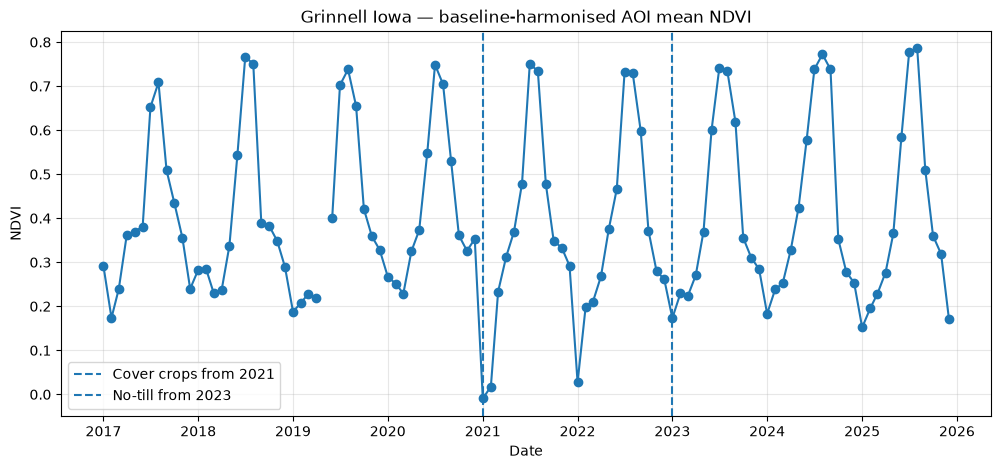

In [6]:
plt.figure(figsize=(12, 5))
plt.plot(ndvi_df["time"], ndvi_df["ndvi"], marker="o", linewidth=1.5)

plt.axvline(pd.Timestamp("2021-01-01"), linestyle="--", label="Cover crops from 2021")
plt.axvline(pd.Timestamp("2023-01-01"), linestyle="--", label="No-till from 2023")

plt.title("Grinnell Iowa — baseline-harmonised AOI mean NDVI")
plt.ylabel("NDVI")
plt.xlabel("Date")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [7]:
summary_df = ndvi_df.copy()
summary_df["year"] = summary_df["time"].dt.year
summary_df["month"] = summary_df["time"].dt.month

# Growing season only, to reduce winter/noise
growing = summary_df[summary_df["month"].isin([6, 7, 8, 9])].copy()

periods = {
    "pre_adoption_2017_2020": growing[(growing["year"] >= 2017) & (growing["year"] <= 2020)],
    "cover_crop_period_2021_2022": growing[(growing["year"] >= 2021) & (growing["year"] <= 2022)],
    "no_till_period_2023_2025": growing[(growing["year"] >= 2023) & (growing["year"] <= 2025)],
}

ndvi_summary = {
    "method": "Sentinel-2 B08/B04 NDVI with baseline harmonisation: subtract 1000 from optical bands on/after 2022-01-25, clamp at 0",
    "scope": "AOI-level growing-season sanity check",
    "warning": "Not field-level proof. Target/control polygons or manual ROIs are still required for a credible Roger-vs-neighbour comparison.",
    "periods": {}
}

for name, subset in periods.items():
    valid = subset["ndvi"].dropna()
    ndvi_summary["periods"][name] = {
        "mean_ndvi": None if valid.empty else round(float(valid.mean()), 4),
        "median_ndvi": None if valid.empty else round(float(valid.median()), 4),
        "max_ndvi": None if valid.empty else round(float(valid.max()), 4),
        "observations": int(valid.count()),
    }

summary_out = DEMO_DATA / "ndvi_summary.json"
summary_out.write_text(json.dumps(ndvi_summary, indent=2), encoding="utf-8")

print("Saved:", summary_out)
print(json.dumps(ndvi_summary, indent=2))

Saved: C:\Users\danie\Desktop\Treefera Hackathon\public\demo-data\ndvi_summary.json
{
  "method": "Sentinel-2 B08/B04 NDVI with baseline harmonisation: subtract 1000 from optical bands on/after 2022-01-25, clamp at 0",
  "scope": "AOI-level growing-season sanity check",
  "warning": "Not field-level proof. Target/control polygons or manual ROIs are still required for a credible Roger-vs-neighbour comparison.",
  "periods": {
    "pre_adoption_2017_2020": {
      "mean_ndvi": 0.6078,
      "median_ndvi": 0.6535,
      "max_ndvi": 0.7658,
      "observations": 16
    },
    "cover_crop_period_2021_2022": {
      "mean_ndvi": 0.621,
      "median_ndvi": 0.6648,
      "max_ndvi": 0.7508,
      "observations": 8
    },
    "no_till_period_2023_2025": {
      "mean_ndvi": 0.6814,
      "median_ndvi": 0.7357,
      "max_ndvi": 0.7856,
      "observations": 12
    }
  }
}


In [8]:
import rasterio

biomass_rows = []

for tif_path in sorted(BIOMASS_ROOT.rglob("*.tif")):
    year_match = re.search(r"(20\d{2})", tif_path.name)
    year = int(year_match.group(1)) if year_match else None
    
    path_lower = str(tif_path).lower()
    category = "above-ground" if "above-ground" in path_lower else "deep"
    
    with rasterio.open(tif_path) as src:
        arr = src.read(1).astype("float32")
        
        if src.nodata is not None:
            arr = np.where(arr == src.nodata, np.nan, arr)
        
        arr = np.where(np.isfinite(arr), arr, np.nan)
        
        biomass_rows.append({
            "category": category,
            "year": year,
            "file": tif_path.name,
            "mean": round(float(np.nanmean(arr)), 6),
            "median": round(float(np.nanmedian(arr)), 6),
            "valid_pixels": int(np.isfinite(arr).sum()),
            "note": "AOI-level biomass context only; coarse/noisy, not field-level proof"
        })

bio_df = pd.DataFrame(biomass_rows).sort_values(["category", "year"])

display(bio_df)

C:\Users\danie\AppData\Local\Temp\ipykernel_13304\1432286027.py:13: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  arr = src.read(1).astype("float32")


,category,year,file,mean,median,valid_pixels,note
0,above-ground,2007,esa_biomass_agb_cog_CLIENT_61785376_2007.tif,4.415443,0.000000,9130,"AOI-level biomass context only; coarse/noisy, ..."
1,above-ground,2010,esa_biomass_agb_cog_CLIENT_61785376_2010.tif,4.271851,0.000000,9130,"AOI-level biomass context only; coarse/noisy, ..."
2,above-ground,2015,esa_biomass_agb_cog_CLIENT_61785376_2015.tif,6.456079,0.000000,9130,"AOI-level biomass context only; coarse/noisy, ..."
3,above-ground,2016,esa_biomass_agb_cog_CLIENT_61785376_2016.tif,12.373275,1.000000,9130,"AOI-level biomass context only; coarse/noisy, ..."
4,above-ground,2017,esa_biomass_agb_cog_CLIENT_61785376_2017.tif,6.261446,0.000000,9130,"AOI-level biomass context only; coarse/noisy, ..."
5,above-ground,2018,esa_biomass_agb_cog_CLIENT_61785376_2018.tif,3.933735,0.000000,9130,"AOI-level biomass context only; coarse/noisy, ..."
6,above-ground,2019,esa_biomass_agb_cog_CLIENT_61785376_2019.tif,5.463965,0.000000,9130,"AOI-level biomass context only; coarse/noisy, ..."
7,above-ground,2020,esa_biomass_agb_cog_CLIENT_61785376_2020.tif,9.386199,0.000000,9130,"AOI-level biomass context only; coarse/noisy, ..."
8,above-ground,2021,esa_biomass_agb_cog_CLIENT_61785376_2021.tif,2.318839,0.000000,9130,"AOI-level biomass context only; coarse/noisy, ..."
9,above-ground,2022,esa_biomass_agb_cog_CLIENT_61785376_2022.tif,3.512815,0.000000,9130,"AOI-level biomass context only; coarse/noisy, ..."


In [9]:
biomass_out = DEMO_DATA / "biomass_timeseries.json"
bio_df.to_json(biomass_out, orient="records", indent=2)

print("Saved:", biomass_out)
print("Rows:", len(bio_df))

Saved: C:\Users\danie\Desktop\Treefera Hackathon\public\demo-data\biomass_timeseries.json
Rows: 22


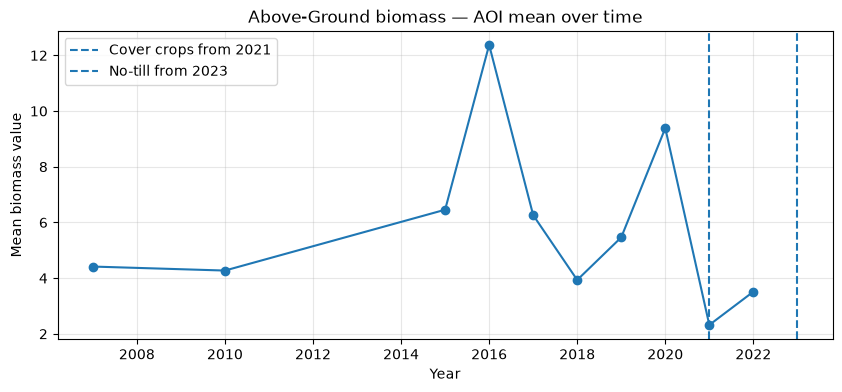

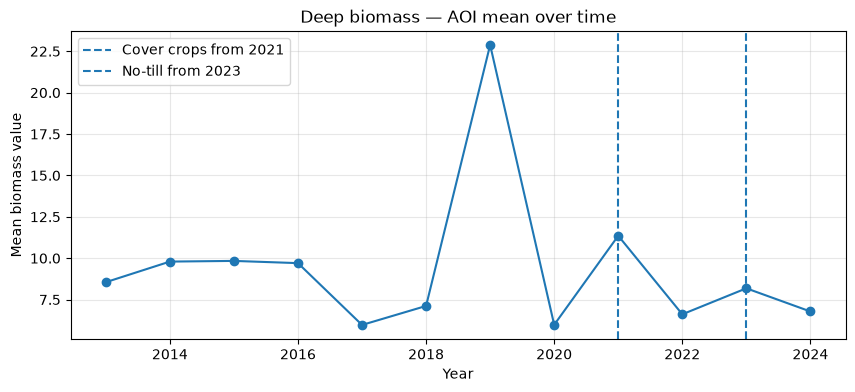

In [10]:
for category, group in bio_df.groupby("category"):
    plt.figure(figsize=(10, 4))
    plt.plot(group["year"], group["mean"], marker="o")
    
    plt.axvline(2021, linestyle="--", label="Cover crops from 2021")
    plt.axvline(2023, linestyle="--", label="No-till from 2023")
    
    plt.title(f"{category.title()} biomass — AOI mean over time")
    plt.xlabel("Year")
    plt.ylabel("Mean biomass value")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

In [11]:
expected_files = [
    "aoi_metadata.json",
    "ndvi_timeseries.json",
    "ndvi_summary.json",
    "biomass_timeseries.json",
]

for filename in expected_files:
    path = DEMO_DATA / filename
    print(filename, "✅" if path.exists() else "❌", path)

aoi_metadata.json ✅ C:\Users\danie\Desktop\Treefera Hackathon\public\demo-data\aoi_metadata.json
ndvi_timeseries.json ✅ C:\Users\danie\Desktop\Treefera Hackathon\public\demo-data\ndvi_timeseries.json
ndvi_summary.json ✅ C:\Users\danie\Desktop\Treefera Hackathon\public\demo-data\ndvi_summary.json
biomass_timeseries.json ✅ C:\Users\danie\Desktop\Treefera Hackathon\public\demo-data\biomass_timeseries.json


In [13]:
from pathlib import Path
import json
from datetime import datetime, timezone

DEMO_DATA = Path(r"C:\Users\danie\Desktop\Treefera Hackathon\public\demo-data")

summary = json.loads((DEMO_DATA / "ndvi_summary.json").read_text(encoding="utf-8"))
aoi = json.loads((DEMO_DATA / "aoi_metadata.json").read_text(encoding="utf-8"))

coords = aoi["coordinates"]
lngs = [p[0] for p in coords]
lats = [p[1] for p in coords]

center = {
    "lat": round(sum(lats) / len(lats), 6),
    "lng": round(sum(lngs) / len(lngs), 6),
}

pre = summary["periods"]["pre_adoption_2017_2020"]["mean_ndvi"]
cover = summary["periods"]["cover_crop_period_2021_2022"]["mean_ndvi"]
notill = summary["periods"]["no_till_period_2023_2025"]["mean_ndvi"]

uplift_pre_to_notill = round(notill - pre, 4)
uplift_percent = round((uplift_pre_to_notill / pre) * 100, 1)

manifest = {
    "schemaVersion": "1.0.0",
    "_comment": "REAL HACKATHON DEMO DATA — generated from local notebook exports. AOI-level signal only; not field-level proof.",
    "generatedAt": datetime.now(timezone.utc).isoformat(),
    "dataSource": "treefera_local_exports",

    "projectName": "Regen Radar",
    "challengeName": "Treefera LCAW 2026 Hackathon — Grinnell Iowa Regen Ag Detection",
    "tagline": "Detecting regenerative agriculture signals from baseline-harmonised satellite time-series data",

    "siteName": aoi["name"],
    "country": aoi["country"],
    "coordinates": center,
    "areaHectares": 6400,
    "dateRange": { "start": "2017-01-01", "end": "2025-12-31" },
    "satellite": "Sentinel-2 L2A monthly median optical reflectance, baseline-harmonised",
    "controlFieldCount": 0,

    "score": 64,
    "scoreLabel": "Moderate AOI-level signal",
    "confidence": {
        "level": "Moderate-low",
        "value": 0.56,
        "note": "Growing-season NDVI rises after known practice-change periods, but this is AOI-level evidence. Field-level target/control polygons are still required."
    },

    "adoptionPeriod": {
        "label": "Known practice-change window",
        "start": "2021-01-01",
        "end": "2025-12-31"
    },

    "factors": [
        {
            "id": "baseline_harmonised_ndvi",
            "label": "Baseline-harmonised NDVI",
            "detail": "Sentinel-2 optical bands were corrected by subtracting 1000 on/after 2022-01-25 before NDVI calculation.",
            "weight": 0.30,
            "direction": "positive"
        },
        {
            "id": "growing_season_uplift",
            "label": "Growing-season NDVI uplift",
            "detail": f"AOI mean growing-season NDVI rises from {pre} pre-adoption to {notill} in the no-till period, an uplift of +{uplift_pre_to_notill} ({uplift_percent}%).",
            "weight": 0.35,
            "direction": "positive"
        },
        {
            "id": "cover_crop_period",
            "label": "Cover crop transition signal",
            "detail": f"Mean growing-season NDVI during the 2021–2022 cover-crop period is {cover}, slightly above the 2017–2020 baseline of {pre}.",
            "weight": 0.15,
            "direction": "positive"
        },
        {
            "id": "biomass_context",
            "label": "Biomass context",
            "detail": "Biomass layers are included as AOI-level context only; they are coarse/noisy and not treated as proof of practice change.",
            "weight": 0.10,
            "direction": "neutral"
        },
        {
            "id": "target_control_missing",
            "label": "Target/control polygons pending",
            "detail": "Current GeoJSON is an 8x8 km AOI box, not individual Roger/control field boundaries.",
            "weight": 0.10,
            "direction": "caution"
        }
    ],

    "aiInsight": {
        "headline": "AOI-level vegetation signal strengthens after practice changes",
        "body": f"Across the Grinnell AOI, baseline-harmonised Sentinel-2 growing-season NDVI increases from {pre} before adoption to {notill} during the no-till period. This is a useful screening signal, but it is not proof of regenerative agriculture without field-level target/control comparison.",
        "model": "Prewritten summary from notebook exports",
        "disclaimer": "Signal, not proof. This is AOI-level evidence and should be validated with field boundaries, controls, weather, crop rotation, and management records."
    },

    "limitations": [
        "Current GeoJSON is an AOI boundary, not individual field polygons.",
        "AOI-level NDVI can mix multiple farms, crop rotations, and management regimes.",
        "Weather, rainfall timing, crop type, and harvest dates can mimic vegetation changes.",
        "Biomass layers are coarse/noisy context and are not field-level proof.",
        "A credible next step is target-vs-control field comparison using Roger's field and matched neighbouring fields."
    ],

    "nextSteps": [
        "Acquire or manually define Roger's target field and 3–5 matched conventional neighbour polygons.",
        "Recalculate NDVI per field rather than across the full AOI.",
        "Compare post-2021 and post-2023 vegetation behaviour against controls.",
        "Add rainfall/weather and crop rotation controls.",
        "Validate signals against farm management records or ground observations."
    ],

    "images": {
        "before": {
            "src": "/demo-data/before.png",
            "label": "Before — pre-practice-change",
            "date": "2020 growing season",
            "caption": "Placeholder visual. Replace with a notebook-exported Sentinel-2 composite if time allows."
        },
        "after": {
            "src": "/demo-data/after.png",
            "label": "After — post-practice-change",
            "date": "2024 growing season",
            "caption": "Placeholder visual. Replace with a notebook-exported Sentinel-2 composite if time allows."
        }
    },

    "timeseriesPath": "/demo-data/ndvi_timeseries.json",
    "ndviSummaryPath": "/demo-data/ndvi_summary.json",
    "biomassTimeseriesPath": "/demo-data/biomass_timeseries.json",
    "aoiMetadataPath": "/demo-data/aoi_metadata.json"
}

out = DEMO_DATA / "manifest.json"
out.write_text(json.dumps(manifest, indent=2), encoding="utf-8")

print("Saved:", out)
print(json.dumps({
    "siteName": manifest["siteName"],
    "dataSource": manifest["dataSource"],
    "scoreLabel": manifest["scoreLabel"],
    "coordinates": manifest["coordinates"],
    "timeseriesPath": manifest["timeseriesPath"]
}, indent=2))

Saved: C:\Users\danie\Desktop\Treefera Hackathon\public\demo-data\manifest.json
{
  "siteName": "Grinnell \u2014 regen ag detection",
  "dataSource": "treefera_local_exports",
  "scoreLabel": "Moderate AOI-level signal",
  "coordinates": {
    "lat": 41.732793,
    "lng": -92.729659
  },
  "timeseriesPath": "/demo-data/ndvi_timeseries.json"
}


In [20]:
from matplotlib.path import Path as MplPath
from pyproj import Transformer

# Recreate xarray NDVI safely
red_xr = harmonise_sentinel2_band(ds["B04"])
nir_xr = harmonise_sentinel2_band(ds["B08"])

ndvi_xr = (nir_xr - red_xr) / (nir_xr + red_xr)
ndvi_xr = ndvi_xr.where(np.isfinite(ndvi_xr))

ROGER_FIELD_PATH = PROJECT_ROOT / "data" / "field-boundaries" / "B-Roger Farm Grinell.geojson"

with open(ROGER_FIELD_PATH, "r", encoding="utf-8") as f:
    roger_geojson = json.load(f)

roger_feature = roger_geojson["features"][0]
roger_lonlat_coords = roger_feature["geometry"]["coordinates"][0]

# Dataset CRS is WGS84 / UTM Zone 15N, EPSG:32615
transformer = Transformer.from_crs("EPSG:4326", "EPSG:32615", always_xy=True)

roger_utm_coords = [
    transformer.transform(lon, lat)
    for lon, lat in roger_lonlat_coords
]

x_vals = ds["x"].values
y_vals = ds["y"].values

xx, yy = np.meshgrid(x_vals, y_vals)
points = np.column_stack([xx.ravel(), yy.ravel()])

polygon_path = MplPath(roger_utm_coords)
inside = polygon_path.contains_points(points).reshape(len(y_vals), len(x_vals))

roger_mask = xr.DataArray(
    inside,
    coords={"y": ds["y"], "x": ds["x"]},
    dims=("y", "x")
)

pixel_count = int(roger_mask.sum().item())

roger_field_ndvi = ndvi_xr.where(roger_mask)
roger_mean_ndvi = roger_field_ndvi.mean(dim=("x", "y"), skipna=True).compute()

roger_df = roger_mean_ndvi.to_dataframe(name="ndvi").reset_index()

if "spatial_ref" in roger_df.columns:
    roger_df = roger_df.drop(columns=["spatial_ref"])

roger_df["time"] = pd.to_datetime(roger_df["time"])
roger_df["scope"] = "roger_target_field"
roger_df["method"] = "sentinel2_baseline_harmonised_polygon_mask_utm15n"
roger_df["note"] = "Roger target field polygon reprojected to UTM Zone 15N; no neighbour controls applied yet"

roger_export = roger_df.copy()
roger_export["time"] = roger_export["time"].dt.strftime("%Y-%m-%d")

roger_out = DEMO_DATA / "roger_field_ndvi_timeseries.json"
roger_export.to_json(roger_out, orient="records", indent=2)

roger_meta = {
    "name": "Roger Farm target field",
    "geometry_type": roger_feature["geometry"]["type"],
    "source_crs": "EPSG:4326",
    "analysis_crs": "EPSG:32615",
    "coordinates_lonlat": roger_lonlat_coords,
    "coordinates_utm15n": [[round(x, 3), round(y, 3)] for x, y in roger_utm_coords],
    "estimated_pixel_count": pixel_count,
    "note": "True polygon mask over Sentinel-2 UTM pixels. Controls still required for target-vs-control comparison."
}

roger_meta_out = DEMO_DATA / "roger_field_metadata.json"
roger_meta_out.write_text(json.dumps(roger_meta, indent=2), encoding="utf-8")

print("Saved:", roger_out)
print("Saved:", roger_meta_out)
print("Estimated target pixels:", pixel_count)
display(roger_df.head())
display(roger_df.tail())

Saved: C:\Users\danie\Desktop\Treefera Hackathon\public\demo-data\roger_field_ndvi_timeseries.json
Saved: C:\Users\danie\Desktop\Treefera Hackathon\public\demo-data\roger_field_metadata.json
Estimated target pixels: 3608


,time,ndvi,scope,method,note
0,2017-01-01,0.296056,roger_target_field,sentinel2_baseline_harmonised_polygon_mask_utm15n,Roger target field polygon reprojected to UTM ...
1,2017-02-01,NaN,roger_target_field,sentinel2_baseline_harmonised_polygon_mask_utm15n,Roger target field polygon reprojected to UTM ...
2,2017-03-01,0.226677,roger_target_field,sentinel2_baseline_harmonised_polygon_mask_utm15n,Roger target field polygon reprojected to UTM ...
3,2017-04-01,0.306043,roger_target_field,sentinel2_baseline_harmonised_polygon_mask_utm15n,Roger target field polygon reprojected to UTM ...
4,2017-05-01,0.281006,roger_target_field,sentinel2_baseline_harmonised_polygon_mask_utm15n,Roger target field polygon reprojected to UTM ...


,time,ndvi,scope,method,note
103,2025-08-01,0.715182,roger_target_field,sentinel2_baseline_harmonised_polygon_mask_utm15n,Roger target field polygon reprojected to UTM ...
104,2025-09-01,0.465745,roger_target_field,sentinel2_baseline_harmonised_polygon_mask_utm15n,Roger target field polygon reprojected to UTM ...
105,2025-10-01,0.320408,roger_target_field,sentinel2_baseline_harmonised_polygon_mask_utm15n,Roger target field polygon reprojected to UTM ...
106,2025-11-01,0.351926,roger_target_field,sentinel2_baseline_harmonised_polygon_mask_utm15n,Roger target field polygon reprojected to UTM ...
107,2025-12-01,NaN,roger_target_field,sentinel2_baseline_harmonised_polygon_mask_utm15n,Roger target field polygon reprojected to UTM ...


In [21]:
roger_summary_df = roger_df.copy()
roger_summary_df["year"] = roger_summary_df["time"].dt.year
roger_summary_df["month"] = roger_summary_df["time"].dt.month

roger_growing = roger_summary_df[roger_summary_df["month"].isin([6, 7, 8, 9])].copy()

roger_periods = {
    "pre_adoption_2017_2020": roger_growing[(roger_growing["year"] >= 2017) & (roger_growing["year"] <= 2020)],
    "cover_crop_period_2021_2022": roger_growing[(roger_growing["year"] >= 2021) & (roger_growing["year"] <= 2022)],
    "no_till_period_2023_2025": roger_growing[(roger_growing["year"] >= 2023) & (roger_growing["year"] <= 2025)],
}

roger_summary = {
    "method": "Roger target field NDVI extracted using true polygon mask reprojected from EPSG:4326 to EPSG:32615, with Sentinel-2 baseline harmonisation applied first",
    "scope": "Roger target field polygon",
    "warning": "Target field only. Neighbour/control polygons are still required for full target-vs-control proof.",
    "estimated_pixel_count": int(pixel_count),
    "periods": {}
}

for name, subset in roger_periods.items():
    valid = subset["ndvi"].dropna()
    roger_summary["periods"][name] = {
        "mean_ndvi": None if valid.empty else round(float(valid.mean()), 4),
        "median_ndvi": None if valid.empty else round(float(valid.median()), 4),
        "max_ndvi": None if valid.empty else round(float(valid.max()), 4),
        "observations": int(valid.count()),
    }

roger_summary_out = DEMO_DATA / "roger_field_ndvi_summary.json"
roger_summary_out.write_text(json.dumps(roger_summary, indent=2), encoding="utf-8")

print("Saved:", roger_summary_out)
print(json.dumps(roger_summary, indent=2))

Saved: C:\Users\danie\Desktop\Treefera Hackathon\public\demo-data\roger_field_ndvi_summary.json
{
  "method": "Roger target field NDVI extracted using true polygon mask reprojected from EPSG:4326 to EPSG:32615, with Sentinel-2 baseline harmonisation applied first",
  "scope": "Roger target field polygon",
  "warning": "Target field only. Neighbour/control polygons are still required for full target-vs-control proof.",
  "estimated_pixel_count": 3608,
  "periods": {
    "pre_adoption_2017_2020": {
      "mean_ndvi": 0.5923,
      "median_ndvi": 0.5357,
      "max_ndvi": 0.8206,
      "observations": 14
    },
    "cover_crop_period_2021_2022": {
      "mean_ndvi": 0.5865,
      "median_ndvi": 0.5627,
      "max_ndvi": 0.7246,
      "observations": 8
    },
    "no_till_period_2023_2025": {
      "mean_ndvi": 0.6303,
      "median_ndvi": 0.6937,
      "max_ndvi": 0.7281,
      "observations": 12
    }
  }
}


In [22]:
manifest_path = DEMO_DATA / "manifest.json"
manifest = json.loads(manifest_path.read_text(encoding="utf-8"))

roger_summary = json.loads((DEMO_DATA / "roger_field_ndvi_summary.json").read_text(encoding="utf-8"))

pre = roger_summary["periods"]["pre_adoption_2017_2020"]["mean_ndvi"]
cover = roger_summary["periods"]["cover_crop_period_2021_2022"]["mean_ndvi"]
notill = roger_summary["periods"]["no_till_period_2023_2025"]["mean_ndvi"]

uplift = round(notill - pre, 4)
uplift_percent = round((uplift / pre) * 100, 1)

manifest["score"] = 68
manifest["scoreLabel"] = "Moderate target-field signal"
manifest["confidence"] = {
    "level": "Moderate",
    "value": 0.62,
    "note": "Roger's target field shows higher growing-season NDVI during the no-till period, but neighbour/control polygons are still required for proof."
}

manifest["factors"] = [
    {
        "id": "roger_polygon_extract",
        "label": "Roger field polygon extracted",
        "detail": f"NDVI was extracted from Roger's target field using a true polygon mask over {roger_summary['estimated_pixel_count']} Sentinel-2 pixels.",
        "weight": 0.30,
        "direction": "positive"
    },
    {
        "id": "roger_notill_uplift",
        "label": "No-till period NDVI uplift",
        "detail": f"Roger field growing-season NDVI rises from {pre} pre-adoption to {notill} in the no-till period, an uplift of +{uplift} ({uplift_percent}%).",
        "weight": 0.35,
        "direction": "positive"
    },
    {
        "id": "baseline_harmonised_ndvi",
        "label": "Baseline-harmonised Sentinel-2",
        "detail": "Optical bands were corrected by subtracting 1000 on/after 2022-01-25 before calculating NDVI.",
        "weight": 0.20,
        "direction": "positive"
    },
    {
        "id": "controls_pending",
        "label": "Neighbour controls pending",
        "detail": "Current result is target-field only. Matched conventional neighbour polygons are still needed for full target-vs-control proof.",
        "weight": 0.15,
        "direction": "caution"
    }
]

manifest["aiInsight"] = {
    "headline": "Roger field shows a moderate post-practice vegetation signal",
    "body": f"Using the real Roger Farm polygon, baseline-harmonised Sentinel-2 NDVI rises from {pre} before adoption to {notill} during the no-till period. This is stronger than AOI-only evidence because it uses the target field boundary, but it remains a signal rather than proof until matched neighbour controls are added.",
    "model": "Prewritten summary from notebook exports",
    "disclaimer": "Signal, not proof. Target-field evidence should be validated with neighbour controls, weather, crop rotation, and farm management records."
}

manifest["rogerFieldTimeseriesPath"] = "/demo-data/roger_field_ndvi_timeseries.json"
manifest["rogerFieldSummaryPath"] = "/demo-data/roger_field_ndvi_summary.json"
manifest["rogerFieldMetadataPath"] = "/demo-data/roger_field_metadata.json"

manifest_path.write_text(json.dumps(manifest, indent=2), encoding="utf-8")

print("Saved:", manifest_path)
print("Roger uplift:", uplift, f"({uplift_percent}%)")
print("Score label:", manifest["scoreLabel"])

Saved: C:\Users\danie\Desktop\Treefera Hackathon\public\demo-data\manifest.json
Roger uplift: 0.038 (6.4%)
Score label: Moderate target-field signal


In [23]:
aoi_ts = pd.read_json(DEMO_DATA / "ndvi_timeseries.json")
roger_ts = pd.read_json(DEMO_DATA / "roger_field_ndvi_timeseries.json")

aoi_ts = aoi_ts.rename(columns={"ndvi": "aoi_ndvi"})
roger_ts = roger_ts.rename(columns={"ndvi": "roger_ndvi"})

comparison = pd.merge(
    roger_ts[["time", "roger_ndvi"]],
    aoi_ts[["time", "aoi_ndvi"]],
    on="time",
    how="outer"
)

comparison["time"] = pd.to_datetime(comparison["time"])
comparison["difference_roger_minus_aoi"] = comparison["roger_ndvi"] - comparison["aoi_ndvi"]
comparison["scope"] = "roger_target_field_vs_aoi_background"
comparison["note"] = "Comparison against full AOI background only, not matched neighbour controls"

comparison_export = comparison.copy()
comparison_export["time"] = comparison_export["time"].dt.strftime("%Y-%m-%d")

out = DEMO_DATA / "roger_vs_aoi_ndvi_timeseries.json"
comparison_export.to_json(out, orient="records", indent=2)

print("Saved:", out)
display(comparison.head())
display(comparison.tail())

Saved: C:\Users\danie\Desktop\Treefera Hackathon\public\demo-data\roger_vs_aoi_ndvi_timeseries.json


,time,roger_ndvi,aoi_ndvi,difference_roger_minus_aoi,scope,note
0,2017-01-01,0.296056,0.291454,0.004602,roger_target_field_vs_aoi_background,"Comparison against full AOI background only, n..."
1,2017-02-01,NaN,0.173636,NaN,roger_target_field_vs_aoi_background,"Comparison against full AOI background only, n..."
2,2017-03-01,0.226677,0.239216,-0.012539,roger_target_field_vs_aoi_background,"Comparison against full AOI background only, n..."
3,2017-04-01,0.306043,0.362733,-0.056689,roger_target_field_vs_aoi_background,"Comparison against full AOI background only, n..."
4,2017-05-01,0.281006,0.369635,-0.088628,roger_target_field_vs_aoi_background,"Comparison against full AOI background only, n..."


,time,roger_ndvi,aoi_ndvi,difference_roger_minus_aoi,scope,note
103,2025-08-01,0.715182,0.785555,-0.070372,roger_target_field_vs_aoi_background,"Comparison against full AOI background only, n..."
104,2025-09-01,0.465745,0.510303,-0.044557,roger_target_field_vs_aoi_background,"Comparison against full AOI background only, n..."
105,2025-10-01,0.320408,0.360030,-0.039622,roger_target_field_vs_aoi_background,"Comparison against full AOI background only, n..."
106,2025-11-01,0.351926,0.318755,0.033170,roger_target_field_vs_aoi_background,"Comparison against full AOI background only, n..."
107,2025-12-01,NaN,0.172023,NaN,roger_target_field_vs_aoi_background,"Comparison against full AOI background only, n..."


In [24]:
manifest_path = DEMO_DATA / "manifest.json"
manifest = json.loads(manifest_path.read_text(encoding="utf-8"))

manifest["rogerVsAoiTimeseriesPath"] = "/demo-data/roger_vs_aoi_ndvi_timeseries.json"

manifest_path.write_text(json.dumps(manifest, indent=2), encoding="utf-8")

print("Saved:", manifest_path)
print("rogerVsAoiTimeseriesPath:", manifest["rogerVsAoiTimeseriesPath"])

Saved: C:\Users\danie\Desktop\Treefera Hackathon\public\demo-data\manifest.json
rogerVsAoiTimeseriesPath: /demo-data/roger_vs_aoi_ndvi_timeseries.json


In [25]:
roger_vs_aoi = pd.read_json(DEMO_DATA / "roger_vs_aoi_ndvi_timeseries.json")
roger_vs_aoi["time"] = pd.to_datetime(roger_vs_aoi["time"])
roger_vs_aoi["year"] = roger_vs_aoi["time"].dt.year
roger_vs_aoi["month"] = roger_vs_aoi["time"].dt.month

growing = roger_vs_aoi[roger_vs_aoi["month"].isin([6, 7, 8, 9])].copy()

periods = {
    "pre_adoption_2017_2020": growing[(growing["year"] >= 2017) & (growing["year"] <= 2020)],
    "cover_crop_period_2021_2022": growing[(growing["year"] >= 2021) & (growing["year"] <= 2022)],
    "no_till_period_2023_2025": growing[(growing["year"] >= 2023) & (growing["year"] <= 2025)],
}

comparison_summary = {
    "scope": "Roger target field vs AOI background",
    "warning": "AOI background is not matched neighbour controls.",
    "periods": {}
}

for name, subset in periods.items():
    valid = subset.dropna(subset=["roger_ndvi", "aoi_ndvi"])
    comparison_summary["periods"][name] = {
        "roger_mean_ndvi": None if valid.empty else round(float(valid["roger_ndvi"].mean()), 4),
        "aoi_mean_ndvi": None if valid.empty else round(float(valid["aoi_ndvi"].mean()), 4),
        "roger_minus_aoi": None if valid.empty else round(float(valid["difference_roger_minus_aoi"].mean()), 4),
        "observations": int(len(valid)),
    }

out = DEMO_DATA / "roger_vs_aoi_ndvi_summary.json"
out.write_text(json.dumps(comparison_summary, indent=2), encoding="utf-8")

print("Saved:", out)
print(json.dumps(comparison_summary, indent=2))

Saved: C:\Users\danie\Desktop\Treefera Hackathon\public\demo-data\roger_vs_aoi_ndvi_summary.json
{
  "scope": "Roger target field vs AOI background",
  "warning": "AOI background is not matched neighbour controls.",
  "periods": {
    "pre_adoption_2017_2020": {
      "roger_mean_ndvi": 0.5923,
      "aoi_mean_ndvi": 0.6148,
      "roger_minus_aoi": -0.0225,
      "observations": 14
    },
    "cover_crop_period_2021_2022": {
      "roger_mean_ndvi": 0.5865,
      "aoi_mean_ndvi": 0.621,
      "roger_minus_aoi": -0.0345,
      "observations": 8
    },
    "no_till_period_2023_2025": {
      "roger_mean_ndvi": 0.6303,
      "aoi_mean_ndvi": 0.6814,
      "roger_minus_aoi": -0.0511,
      "observations": 12
    }
  }
}


In [27]:
import requests
from urllib.parse import urlencode

lat = 41.7498
lon = -92.7442

params = {
    "latitude": lat,
    "longitude": lon,
    "start_date": "2017-01-01",
    "end_date": "2025-12-31",
    "daily": ",".join([
        "temperature_2m_mean",
        "temperature_2m_max",
        "temperature_2m_min",
        "precipitation_sum",
        "rain_sum",
        "shortwave_radiation_sum",
        "et0_fao_evapotranspiration",
        "soil_moisture_0_to_7cm_mean",
        "soil_moisture_7_to_28cm_mean"
    ]),
    "timezone": "America/Chicago"
}

url = "https://archive-api.open-meteo.com/v1/archive?" + urlencode(params)

response = requests.get(url, timeout=60)
response.raise_for_status()

weather_json = response.json()
weather_daily = pd.DataFrame(weather_json["daily"])
weather_daily["time"] = pd.to_datetime(weather_daily["time"])

daily_out = DEMO_DATA / "roger_weather_daily.json"
weather_daily_export = weather_daily.copy()
weather_daily_export["time"] = weather_daily_export["time"].dt.strftime("%Y-%m-%d")
weather_daily_export.to_json(daily_out, orient="records", indent=2)

weather_daily["month"] = weather_daily["time"].dt.to_period("M").dt.to_timestamp()

weather_monthly = weather_daily.groupby("month", as_index=False).agg({
    "temperature_2m_mean": "mean",
    "temperature_2m_max": "mean",
    "temperature_2m_min": "mean",
    "precipitation_sum": "sum",
    "rain_sum": "sum",
    "shortwave_radiation_sum": "sum",
    "et0_fao_evapotranspiration": "sum",
    "soil_moisture_0_to_7cm_mean": "mean",
    "soil_moisture_7_to_28cm_mean": "mean"
})

weather_monthly = weather_monthly.round(4)

monthly_out = DEMO_DATA / "roger_weather_monthly.json"
weather_monthly_export = weather_monthly.copy()
weather_monthly_export["month"] = weather_monthly_export["month"].dt.strftime("%Y-%m-%d")
weather_monthly_export.to_json(monthly_out, orient="records", indent=2)

print("Saved:", daily_out)
print("Saved:", monthly_out)
display(weather_monthly.head())
display(weather_monthly.tail())

Saved: C:\Users\danie\Desktop\Treefera Hackathon\public\demo-data\roger_weather_daily.json
Saved: C:\Users\danie\Desktop\Treefera Hackathon\public\demo-data\roger_weather_monthly.json


C:\Users\danie\AppData\Local\Temp\ipykernel_13304\1641752955.py:54: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  weather_monthly = weather_monthly.round(4)


,month,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,rain_sum,shortwave_radiation_sum,et0_fao_evapotranspiration,soil_moisture_0_to_7cm_mean,soil_moisture_7_to_28cm_mean
0,2017-01-01,-2.8935,0.8065,-6.3903,52.6,43.3,176.20,23.69,0.3796,0.3745
1,2017-02-01,2.8321,8.5929,-2.4679,36.2,27.7,331.88,49.47,0.3621,0.3640
2,2017-03-01,4.2161,8.5000,0.1935,57.2,47.7,388.40,63.83,0.3646,0.3683
3,2017-04-01,11.7867,16.8733,6.9733,133.3,133.3,485.34,90.73,0.3799,0.3832
4,2017-05-01,15.5516,20.5871,10.2839,76.5,76.5,683.32,130.40,0.3574,0.3625


,month,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,rain_sum,shortwave_radiation_sum,et0_fao_evapotranspiration,soil_moisture_0_to_7cm_mean,soil_moisture_7_to_28cm_mean
103,2025-08-01,21.8290,26.2290,17.6968,50.7,50.7,657.54,125.31,0.2087,0.2374
104,2025-09-01,20.0300,25.3967,15.1667,13.4,13.4,525.75,109.61,0.1819,0.1997
105,2025-10-01,14.2516,19.5484,9.8000,54.6,54.6,379.80,86.50,0.2482,0.2344
106,2025-11-01,4.8267,9.4367,0.6900,48.4,18.6,234.98,40.77,0.2814,0.2871
107,2025-12-01,-3.8774,0.3742,-8.6742,35.3,9.6,183.80,16.97,0.3463,0.3292


In [28]:
roger_ndvi = pd.read_json(DEMO_DATA / "roger_field_ndvi_timeseries.json")
weather = pd.read_json(DEMO_DATA / "roger_weather_monthly.json")

roger_ndvi["time"] = pd.to_datetime(roger_ndvi["time"])
weather["month"] = pd.to_datetime(weather["month"])

merged = pd.merge(
    roger_ndvi[["time", "ndvi"]],
    weather,
    left_on="time",
    right_on="month",
    how="left"
).drop(columns=["month"])

merged = merged.rename(columns={"ndvi": "roger_ndvi"})

# Add lagged precipitation, because vegetation often responds after rainfall rather than instantly
merged["precipitation_previous_month"] = merged["precipitation_sum"].shift(1)
merged["soil_moisture_previous_month"] = merged["soil_moisture_0_to_7cm_mean"].shift(1)

corr_cols = [
    "precipitation_sum",
    "precipitation_previous_month",
    "rain_sum",
    "temperature_2m_mean",
    "shortwave_radiation_sum",
    "et0_fao_evapotranspiration",
    "soil_moisture_0_to_7cm_mean",
    "soil_moisture_previous_month",
    "soil_moisture_7_to_28cm_mean"
]

valid = merged.dropna(subset=["roger_ndvi"])

correlations = {}
for col in corr_cols:
    pair = valid.dropna(subset=[col])
    correlations[col] = None if len(pair) < 3 else round(float(pair["roger_ndvi"].corr(pair[col])), 4)

# Find months where Roger NDVI is unusually low/high compared with its own monthly distribution
merged["month_number"] = merged["time"].dt.month
monthly_stats = merged.groupby("month_number")["roger_ndvi"].agg(["mean", "std"]).reset_index()
merged = merged.merge(monthly_stats, on="month_number", how="left")
merged["ndvi_zscore_for_month"] = (merged["roger_ndvi"] - merged["mean"]) / merged["std"]

outliers = merged[
    merged["ndvi_zscore_for_month"].abs() >= 1.5
][[
    "time",
    "roger_ndvi",
    "ndvi_zscore_for_month",
    "precipitation_sum",
    "precipitation_previous_month",
    "temperature_2m_mean",
    "soil_moisture_0_to_7cm_mean",
    "shortwave_radiation_sum"
]].copy()

outliers["time"] = outliers["time"].dt.strftime("%Y-%m-%d")
outliers = outliers.round(4)

weather_context = {
    "scope": "Roger target field NDVI with monthly weather context",
    "warning": "Correlation is exploratory only. Weather, crop timing, harvest, and management can all affect NDVI.",
    "correlations_with_roger_ndvi": correlations,
    "outlier_months": outliers.to_dict(orient="records"),
    "interpretation": "Weather context helps explain NDVI outliers and prevents blindly attributing vegetation changes to regenerative practices."
}

context_out = DEMO_DATA / "roger_weather_ndvi_context.json"
context_out.write_text(json.dumps(weather_context, indent=2), encoding="utf-8")

merged_export = merged.drop(columns=["mean", "std"], errors="ignore").copy()
merged_export["time"] = merged_export["time"].dt.strftime("%Y-%m-%d")
merged_export = merged_export.round(4)

merged_out = DEMO_DATA / "roger_ndvi_weather_monthly.json"
merged_export.to_json(merged_out, orient="records", indent=2)

print("Saved:", context_out)
print("Saved:", merged_out)
print(json.dumps(weather_context, indent=2))

Saved: C:\Users\danie\Desktop\Treefera Hackathon\public\demo-data\roger_weather_ndvi_context.json
Saved: C:\Users\danie\Desktop\Treefera Hackathon\public\demo-data\roger_ndvi_weather_monthly.json
{
  "scope": "Roger target field NDVI with monthly weather context",
  "warning": "Correlation is exploratory only. Weather, crop timing, harvest, and management can all affect NDVI.",
  "correlations_with_roger_ndvi": {
    "precipitation_sum": 0.1228,
    "precipitation_previous_month": 0.3016,
    "rain_sum": 0.2327,
    "temperature_2m_mean": 0.7661,
    "shortwave_radiation_sum": 0.6316,
    "et0_fao_evapotranspiration": 0.7018,
    "soil_moisture_0_to_7cm_mean": -0.6569,
    "soil_moisture_previous_month": -0.4335,
    "soil_moisture_7_to_28cm_mean": -0.6648
  },
  "outlier_months": [
    {
      "time": "2018-07-01",
      "roger_ndvi": 0.8206,
      "ndvi_zscore_for_month": 1.5267,
      "precipitation_sum": 39.0,
      "precipitation_previous_month": 116.6,
      "temperature_2m_mean"

In [29]:
controls_path = PROJECT_ROOT / "data" / "field-boundaries" / "roger_clean_and_candidate_controls.geojson"

with open(controls_path, "r", encoding="utf-8") as f:
    controls_geojson = json.load(f)

print("Feature count:", len(controls_geojson["features"]))

for i, feature in enumerate(controls_geojson["features"]):
    print("\nFeature", i)
    print("Properties:", feature.get("properties", {}))
    print("Geometry:", feature["geometry"]["type"])
    print("First coordinate:", feature["geometry"]["coordinates"][0][0])

Feature count: 6

Feature 0
Properties: {'name': 'roger_clean', 'role': 'cropland_refined_target'}
Geometry: Polygon
First coordinate: [-92.7464417707826, 41.74995796753606]

Feature 1
Properties: {'name': 'control_1', 'role': 'candidate_control'}
Geometry: Polygon
First coordinate: [-92.76094715713515, 41.753735901305134]

Feature 2
Properties: {'name': 'control_2', 'role': 'candidate_control'}
Geometry: Polygon
First coordinate: [-92.708332945099, 41.76756508372144]

Feature 3
Properties: {'name': 'control_3', 'role': 'candidate_control'}
Geometry: Polygon
First coordinate: [-92.70318310379041, 41.75008603672847]

Feature 4
Properties: {'name': 'control_4', 'role': 'candidate_control'}
Geometry: Polygon
First coordinate: [-92.73668122482667, 41.771850096147034]

Feature 5
Properties: {'name': 'control_5', 'role': 'candidate_control'}
Geometry: Polygon
First coordinate: [-92.74706688761208, 41.77882856291672]


In [30]:
from matplotlib.path import Path as MplPath
from pyproj import Transformer

# Recreate xarray NDVI safely
red_xr = harmonise_sentinel2_band(ds["B04"])
nir_xr = harmonise_sentinel2_band(ds["B08"])

ndvi_xr = (nir_xr - red_xr) / (nir_xr + red_xr)
ndvi_xr = ndvi_xr.where(np.isfinite(ndvi_xr))

# Dataset CRS is WGS84 / UTM Zone 15N, EPSG:32615
transformer = Transformer.from_crs("EPSG:4326", "EPSG:32615", always_xy=True)

x_vals = ds["x"].values
y_vals = ds["y"].values

xx, yy = np.meshgrid(x_vals, y_vals)
points = np.column_stack([xx.ravel(), yy.ravel()])

def polygon_mask_from_lonlat(coords_lonlat):
    coords_utm = [
        transformer.transform(lon, lat)
        for lon, lat in coords_lonlat
    ]
    
    polygon_path = MplPath(coords_utm)
    inside = polygon_path.contains_points(points).reshape(len(y_vals), len(x_vals))
    
    mask = xr.DataArray(
        inside,
        coords={"y": ds["y"], "x": ds["x"]},
        dims=("y", "x")
    )
    
    return mask, coords_utm

field_series = []
field_metadata = []

for feature in controls_geojson["features"]:
    props = feature.get("properties", {})
    name = props.get("name", "unknown")
    role = props.get("role", "unknown")
    geom_type = feature["geometry"]["type"]
    
    if geom_type != "Polygon":
        raise ValueError(f"Unsupported geometry type for {name}: {geom_type}")
    
    coords_lonlat = feature["geometry"]["coordinates"][0]
    mask, coords_utm = polygon_mask_from_lonlat(coords_lonlat)
    
    pixel_count = int(mask.sum().item())
    
    field_ndvi = ndvi_xr.where(mask)
    field_mean = field_ndvi.mean(dim=("x", "y"), skipna=True).compute()
    
    field_df = field_mean.to_dataframe(name="ndvi").reset_index()
    
    if "spatial_ref" in field_df.columns:
        field_df = field_df.drop(columns=["spatial_ref"])
    
    field_df["time"] = pd.to_datetime(field_df["time"])
    field_df["field"] = name
    field_df["role"] = role
    field_df["method"] = "sentinel2_baseline_harmonised_polygon_mask_utm15n"
    field_df["note"] = "Manually drawn GEE candidate-control polygon; signal not proof"
    
    field_series.append(field_df)
    
    field_metadata.append({
        "name": name,
        "role": role,
        "geometry_type": geom_type,
        "source_crs": "EPSG:4326",
        "analysis_crs": "EPSG:32615",
        "estimated_pixel_count": pixel_count,
        "coordinates_lonlat": coords_lonlat,
        "coordinates_utm15n": [[round(x, 3), round(y, 3)] for x, y in coords_utm],
    })

all_fields_long = pd.concat(field_series, ignore_index=True)

# Wide monthly table: one column per field
wide = all_fields_long.pivot_table(
    index="time",
    columns="field",
    values="ndvi",
    aggfunc="mean"
).reset_index()

control_cols = [c for c in wide.columns if str(c).startswith("control_")]

wide["control_avg_ndvi"] = wide[control_cols].mean(axis=1, skipna=True)
wide["roger_clean_minus_control_avg"] = wide["roger_clean"] - wide["control_avg_ndvi"]
wide["scope"] = "roger_clean_vs_candidate_controls"
wide["note"] = "Candidate controls manually selected in Google Earth Engine using satellite basemap, NDVI, and CDL context"

# Export long format too, useful for debugging / future charts
long_export = all_fields_long.copy()
long_export["time"] = long_export["time"].dt.strftime("%Y-%m-%d")

long_out = DEMO_DATA / "field_control_ndvi_long.json"
long_export.to_json(long_out, orient="records", indent=2)

wide_export = wide.copy()
wide_export["time"] = wide_export["time"].dt.strftime("%Y-%m-%d")

wide_out = DEMO_DATA / "roger_clean_vs_controls_ndvi_timeseries.json"
wide_export.to_json(wide_out, orient="records", indent=2)

meta_out = DEMO_DATA / "field_control_metadata.json"
meta_out.write_text(json.dumps(field_metadata, indent=2), encoding="utf-8")

print("Saved:", long_out)
print("Saved:", wide_out)
print("Saved:", meta_out)

print("\nPixel counts:")
for item in field_metadata:
    print(item["name"], item["role"], item["estimated_pixel_count"])

display(wide.head())
display(wide.tail())

Saved: C:\Users\danie\Desktop\Treefera Hackathon\public\demo-data\field_control_ndvi_long.json
Saved: C:\Users\danie\Desktop\Treefera Hackathon\public\demo-data\roger_clean_vs_controls_ndvi_timeseries.json
Saved: C:\Users\danie\Desktop\Treefera Hackathon\public\demo-data\field_control_metadata.json

Pixel counts:
roger_clean cropland_refined_target 1287
control_1 candidate_control 8966
control_2 candidate_control 2510
control_3 candidate_control 4250
control_4 candidate_control 2411
control_5 candidate_control 0


field,time,control_1,control_2,control_3,control_4,roger_clean,control_avg_ndvi,roger_clean_minus_control_avg,scope,note
0,2017-01-01,0.293887,0.179512,0.244461,0.180824,0.248925,0.224671,0.024254,roger_clean_vs_candidate_controls,Candidate controls manually selected in Google...
1,2017-02-01,NaN,NaN,0.181850,NaN,NaN,0.181850,NaN,roger_clean_vs_candidate_controls,Candidate controls manually selected in Google...
2,2017-03-01,0.287343,0.171817,0.211006,0.163613,0.187527,0.208445,-0.020918,roger_clean_vs_candidate_controls,Candidate controls manually selected in Google...
3,2017-04-01,0.469469,0.183499,0.247983,0.146566,0.208570,0.261879,-0.053310,roger_clean_vs_candidate_controls,Candidate controls manually selected in Google...
4,2017-05-01,0.366701,0.181234,0.217010,0.151630,0.189990,0.229144,-0.039154,roger_clean_vs_candidate_controls,Candidate controls manually selected in Google...


field,time,control_1,control_2,control_3,control_4,roger_clean,control_avg_ndvi,roger_clean_minus_control_avg,scope,note
98,2025-08-01,0.898977,0.903001,0.888651,0.899985,0.649243,0.897654,-0.248411,roger_clean_vs_candidate_controls,Candidate controls manually selected in Google...
99,2025-09-01,0.489647,0.544150,0.564311,0.614545,0.426231,0.553163,-0.126932,roger_clean_vs_candidate_controls,Candidate controls manually selected in Google...
100,2025-10-01,0.223003,0.224823,0.200150,0.234056,0.217189,0.220508,-0.003319,roger_clean_vs_candidate_controls,Candidate controls manually selected in Google...
101,2025-11-01,0.249350,0.177098,0.198788,0.191931,0.323768,0.204292,0.119476,roger_clean_vs_candidate_controls,Candidate controls manually selected in Google...
102,2025-12-01,0.146893,0.152303,NaN,NaN,NaN,0.149598,NaN,roger_clean_vs_candidate_controls,Candidate controls manually selected in Google...


In [31]:
controls_ts = pd.read_json(DEMO_DATA / "roger_clean_vs_controls_ndvi_timeseries.json")
controls_ts["time"] = pd.to_datetime(controls_ts["time"])
controls_ts["year"] = controls_ts["time"].dt.year
controls_ts["month"] = controls_ts["time"].dt.month

# Use growing season only
growing = controls_ts[controls_ts["month"].isin([6, 7, 8, 9])].copy()

# Only use valid controls that actually exist and have data
control_cols = [
    col for col in controls_ts.columns
    if col.startswith("control_") and controls_ts[col].notna().sum() > 0
]

print("Valid control columns:", control_cols)

periods = {
    "pre_adoption_2017_2020": growing[(growing["year"] >= 2017) & (growing["year"] <= 2020)],
    "cover_crop_period_2021_2022": growing[(growing["year"] >= 2021) & (growing["year"] <= 2022)],
    "no_till_period_2023_2025": growing[(growing["year"] >= 2023) & (growing["year"] <= 2025)],
}

control_summary = {
    "scope": "Roger clean cropland ROI vs manually selected candidate controls",
    "warning": "Controls were manually selected in Google Earth Engine using satellite basemap, NDVI, and CDL context. They are candidate controls, not ground-truthed matched controls.",
    "excluded_controls": ["control_5"],
    "valid_controls": control_cols,
    "periods": {}
}

for name, subset in periods.items():
    valid = subset.dropna(subset=["roger_clean", "control_avg_ndvi"])
    
    control_summary["periods"][name] = {
        "roger_clean_mean_ndvi": None if valid.empty else round(float(valid["roger_clean"].mean()), 4),
        "control_avg_mean_ndvi": None if valid.empty else round(float(valid["control_avg_ndvi"].mean()), 4),
        "roger_minus_control_avg": None if valid.empty else round(float(valid["roger_clean_minus_control_avg"].mean()), 4),
        "observations": int(len(valid)),
    }

out = DEMO_DATA / "roger_clean_vs_controls_ndvi_summary.json"
out.write_text(json.dumps(control_summary, indent=2), encoding="utf-8")

print("Saved:", out)
print(json.dumps(control_summary, indent=2))

Valid control columns: ['control_1', 'control_2', 'control_3', 'control_4', 'control_avg_ndvi']
Saved: C:\Users\danie\Desktop\Treefera Hackathon\public\demo-data\roger_clean_vs_controls_ndvi_summary.json
{
  "scope": "Roger clean cropland ROI vs manually selected candidate controls",
  "warning": "Controls were manually selected in Google Earth Engine using satellite basemap, NDVI, and CDL context. They are candidate controls, not ground-truthed matched controls.",
  "excluded_controls": [
    "control_5"
  ],
  "valid_controls": [
    "control_1",
    "control_2",
    "control_3",
    "control_4",
    "control_avg_ndvi"
  ],
  "periods": {
    "pre_adoption_2017_2020": {
      "roger_clean_mean_ndvi": 0.6232,
      "control_avg_mean_ndvi": 0.6272,
      "roger_minus_control_avg": -0.004,
      "observations": 14
    },
    "cover_crop_period_2021_2022": {
      "roger_clean_mean_ndvi": 0.6538,
      "control_avg_mean_ndvi": 0.6519,
      "roger_minus_control_avg": 0.0019,
      "obser

In [32]:
summary_path = DEMO_DATA / "roger_clean_vs_controls_ndvi_summary.json"
summary = json.loads(summary_path.read_text(encoding="utf-8"))

summary["valid_controls"] = ["control_1", "control_2", "control_3", "control_4"]
summary["interpretation"] = (
    "Roger's cropland-refined ROI shows a within-field NDVI uplift from pre-adoption to the no-till period, "
    "but the candidate control average rises more strongly. This lowers confidence in attributing the uplift "
    "to regenerative practice alone and highlights the need for crop-type matched, ground-truthed controls."
)

summary_path.write_text(json.dumps(summary, indent=2), encoding="utf-8")

print("Saved:", summary_path)
print(json.dumps(summary, indent=2))

Saved: C:\Users\danie\Desktop\Treefera Hackathon\public\demo-data\roger_clean_vs_controls_ndvi_summary.json
{
  "scope": "Roger clean cropland ROI vs manually selected candidate controls",
  "warning": "Controls were manually selected in Google Earth Engine using satellite basemap, NDVI, and CDL context. They are candidate controls, not ground-truthed matched controls.",
  "excluded_controls": [
    "control_5"
  ],
  "valid_controls": [
    "control_1",
    "control_2",
    "control_3",
    "control_4"
  ],
  "periods": {
    "pre_adoption_2017_2020": {
      "roger_clean_mean_ndvi": 0.6232,
      "control_avg_mean_ndvi": 0.6272,
      "roger_minus_control_avg": -0.004,
      "observations": 14
    },
    "cover_crop_period_2021_2022": {
      "roger_clean_mean_ndvi": 0.6538,
      "control_avg_mean_ndvi": 0.6519,
      "roger_minus_control_avg": 0.0019,
      "observations": 8
    },
    "no_till_period_2023_2025": {
      "roger_clean_mean_ndvi": 0.6785,
      "control_avg_mean_ndvi

In [33]:
manifest_path = DEMO_DATA / "manifest.json"
manifest = json.loads(manifest_path.read_text(encoding="utf-8"))

manifest["fieldControlLongPath"] = "/demo-data/field_control_ndvi_long.json"
manifest["fieldControlMetadataPath"] = "/demo-data/field_control_metadata.json"
manifest["rogerCleanVsControlsTimeseriesPath"] = "/demo-data/roger_clean_vs_controls_ndvi_timeseries.json"
manifest["rogerCleanVsControlsSummaryPath"] = "/demo-data/roger_clean_vs_controls_ndvi_summary.json"

manifest["score"] = 58
manifest["scoreLabel"] = "Moderate signal, controls challenge attribution"
manifest["confidence"] = {
    "level": "Moderate-low",
    "value": 0.48,
    "note": "Roger's clean cropland ROI improves after practice changes, but candidate controls improve more strongly, so attribution remains uncertain."
}

manifest["aiInsight"] = {
    "headline": "Roger field improves, but controls challenge attribution",
    "body": "Roger's cropland-refined ROI shows a within-field NDVI uplift from pre-adoption to the no-till period. However, manually selected candidate controls rise more strongly, which lowers confidence that the uplift can be attributed to regenerative practice alone. This is signal, not proof, and shows why crop-type matched controls and ground validation matter.",
    "model": "Prewritten summary from notebook exports",
    "disclaimer": "Signal, not proof. Candidate controls were manually selected using GEE, satellite basemap, NDVI and CDL context; they are not ground-truthed matched controls."
}

manifest["limitations"] = [
    "Roger's clean cropland ROI shows within-field NDVI uplift, but candidate controls rise more strongly.",
    "Candidate controls were manually selected in Google Earth Engine and are not ground-truthed matched controls.",
    "The original Roger parcel appears to include non-crop/residential edge pixels, so a cropland-refined ROI was used for cleaner analysis.",
    "Weather, crop rotation, harvest timing, and management records need to be checked.",
    "This is a reproducible verification workflow, not proof of regenerative agriculture impact."
]

manifest_path.write_text(json.dumps(manifest, indent=2), encoding="utf-8")

print("Saved:", manifest_path)
print("Score label:", manifest["scoreLabel"])
print("Confidence:", manifest["confidence"])

Saved: C:\Users\danie\Desktop\Treefera Hackathon\public\demo-data\manifest.json
Score label: Moderate signal, controls challenge attribution
Confidence: {'level': 'Moderate-low', 'value': 0.48, 'note': "Roger's clean cropland ROI improves after practice changes, but candidate controls improve more strongly, so attribution remains uncertain."}
